`pandoraspacecraft` is a tool to get access to the current TLE and SPK for the NASA Pandora Smallsat. `pandoraspacecraft` will give you positions and velocities of the spacecraft with respect to other bodies in the solar system. 

In [1]:
import pandoraspacecraft as psc
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt

To use the tool, initiate the `Spacecraft` object

In [2]:
ps = psc.PandoraSpacecraft()
ps

PandoraSpacecraft

This object has methods and properties to help you understand Pandora's orbital properties. You will need to input a time where you want these properties to be evaluated. To do this, you will use `astropy.time.Time` objects, or you can input times in JD.

You can find the start time of the validity range for the TLEs/SPKs of Pandora using `start_time`

In [3]:
ps.start_time

<Time object: scale='utc' format='datetime' value=2026-01-09 18:20:11.200186>

And the end time of the validity range using `end_time`

In [4]:
ps.end_time

<Time object: scale='utc' format='datetime' value=2026-01-13 18:20:11.200071>

Make sure you have the most up to date version of the package to ensure you have the most up-to-date TLEs and SPKs to work with.


Below is an example of how to get the position of Pandora. The function below makes a range of times for 20 days at the beginning of the mission.

In [5]:
t = Time(np.linspace(ps.start_time.jd + 10, ps.start_time.jd + 11, 10000), format='jd')

In [6]:
ps.get_spacecraft_position(t)

array([[-7.25329711e+07,  1.16987866e+08,  5.07400247e+07],
       [-7.25332544e+07,  1.16987726e+08,  5.07400003e+07],
       [-7.25335379e+07,  1.16987585e+08,  5.07399753e+07],
       ...,
       [-7.48032555e+07,  1.15805821e+08,  5.02224360e+07],
       [-7.48034973e+07,  1.15805686e+08,  5.02224454e+07],
       [-7.48037397e+07,  1.15805550e+08,  5.02224546e+07]])

This defaults to the position with respect to the solar system barycenter. You can change the body in the function call.

In [7]:
ps.get_spacecraft_position(t, "earth")

array([[2975.23513155,  179.87878441, 6310.8892234 ],
       [2920.52620648,  155.65154759, 6336.9806534 ],
       [2865.56269627,  131.41074279, 6362.51818976],
       ...,
       [6305.4089889 , 2165.34413103, 2084.71817029],
       [6289.87039697, 2150.13556083, 2146.27656521],
       [6273.78216736, 2134.73910198, 2207.6468991 ]])

There are handy plotting functions in the package to help you

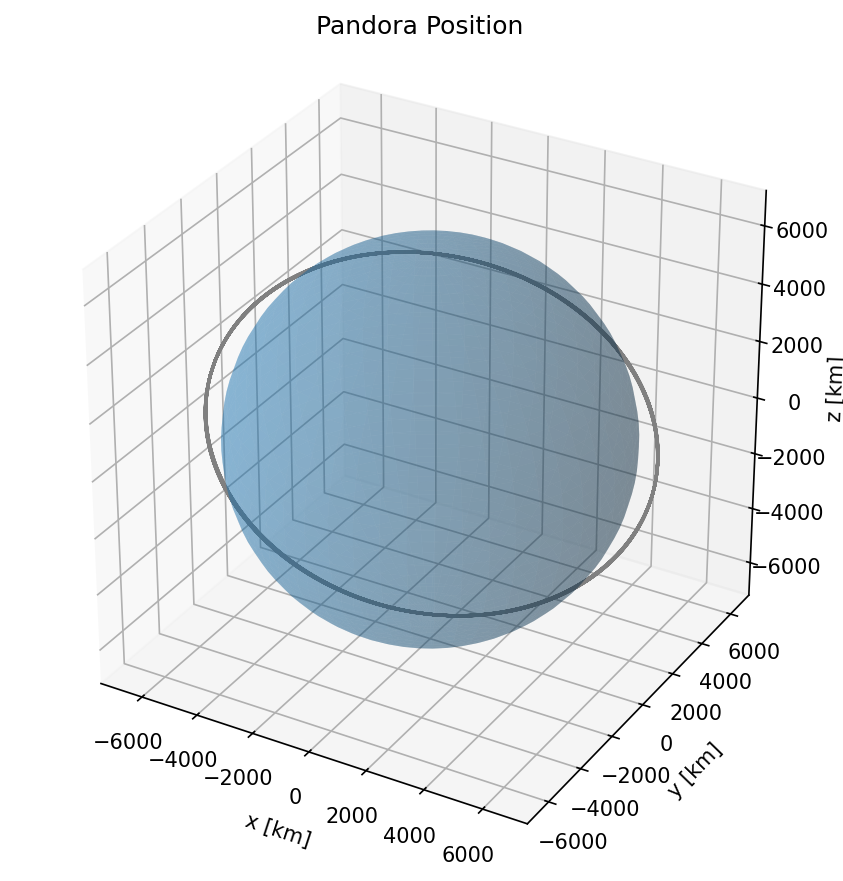

In [8]:
ax = ps.plot_earth()
ps.plot_position(t, ax=ax);

You can get the velocity of the spacecraft too

In [9]:
ps.get_spacecraft_velocity(t)

array([[-32.76861617, -16.29798006,  -2.79954023],
       [-32.79832951, -16.29971498,  -2.86353004],
       [-32.82748893, -16.3012054 ,  -2.9277794 ],
       ...,
       [-27.95336352, -15.66691164,   1.10038331],
       [-28.01702533, -15.6887751 ,   1.0789124 ],
       [-28.08052663, -15.7104836 ,   1.05681842]])

The light travel time to a particular body

In [10]:
ps.get_spacecraft_light_travel_time(t, "earth")

array([0.0232807 , 0.02328053, 0.02328037, ..., 0.0233001 , 0.02329989,
       0.02329967])

The longitude and latitude of the point on earth directly below Pandora

In [11]:
lon, lat = ps.get_earth_subpoint(t)

[Text(0.5, 0, 'Longitude [deg]'), Text(0, 0.5, 'Latitude [deg]')]

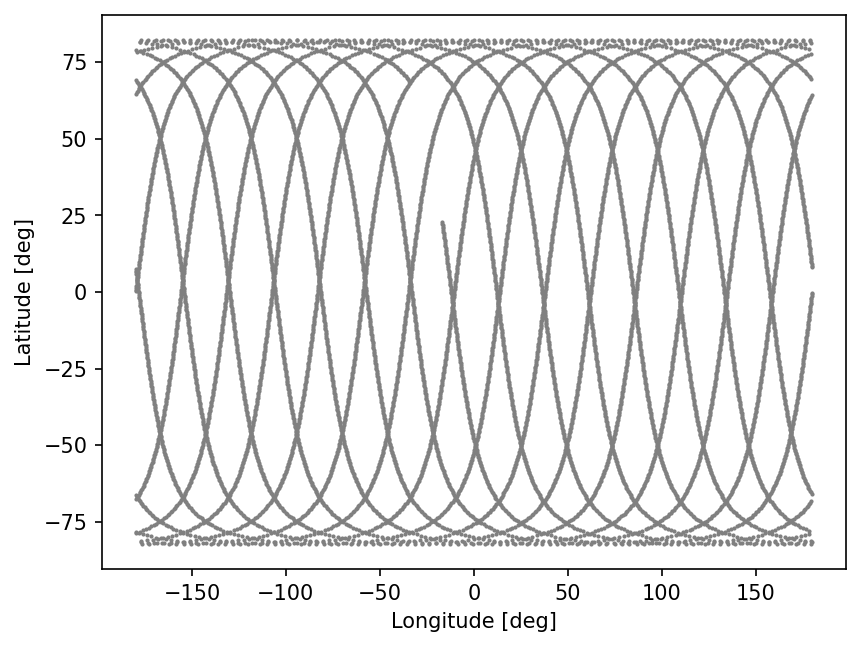

In [12]:
fig, ax = plt.subplots(dpi=150)
ax.scatter(lon, lat, s=1, c='grey')
ax.set(xlabel='Longitude [deg]', ylabel='Latitude [deg]')

The incidene angle of sunlight on the earth below pandora, which can be used to determine if it is "day" below pandora.

Day is where the incidence angle is less than 90 degrees

In [13]:
inc = ps.get_earth_illumination(t)

[Text(0.5, 0, 'Longitude [deg]'), Text(0, 0.5, 'Latitude [deg]')]

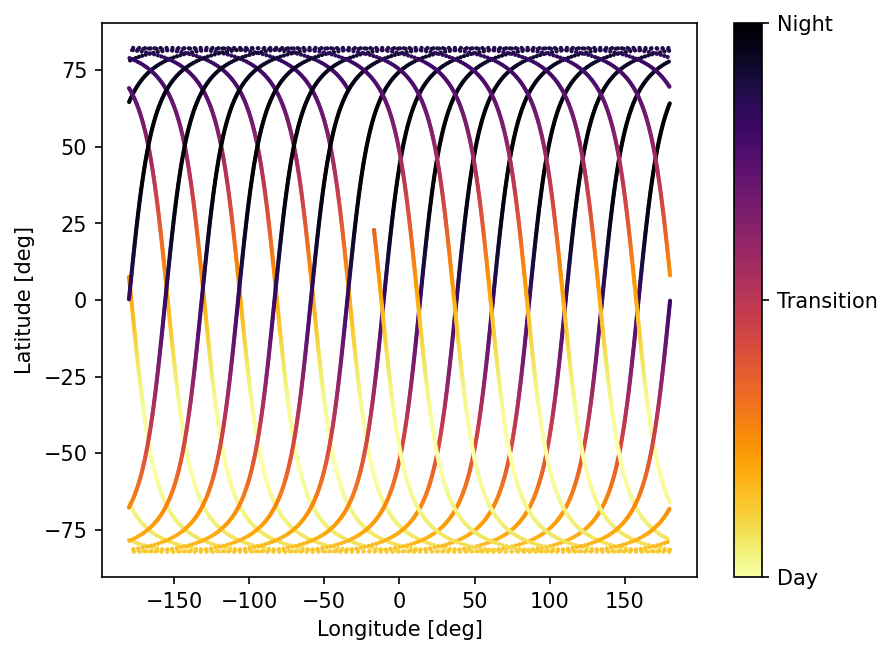

In [14]:
fig, ax = plt.subplots(dpi=150)
im = ax.scatter(lon, lat, s=1, c=inc/90, cmap='inferno_r')
cbar = plt.colorbar(im, ax=ax)
cbar.set_ticks([inc.min()/90, 1, inc.max()/90])
cbar.set_ticklabels(["Day", "Transition", "Night"])
ax.set(xlabel='Longitude [deg]', ylabel='Latitude [deg]')

The period of Pandora is not fixed, because the orbit precesses and changes. You can use the `get_period` function to find the period as a function of time.

[Text(0.5, 0, 'Time [JD]'), Text(0, 0.5, 'Period [minutes]')]

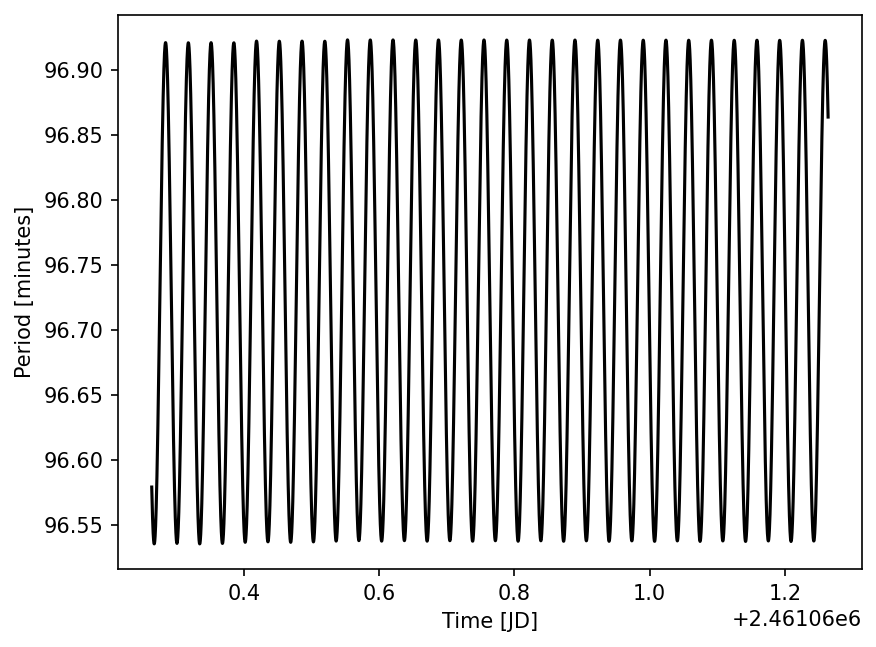

In [15]:
fig, ax = plt.subplots(dpi=150)
ax.plot(t.jd, ps.get_period(t), c='k')
ax.set(xlabel='Time [JD]', ylabel='Period [minutes]')

You can also easily plot the altitude of the spacecraft in kilometers.

[Text(0.5, 0, 'Time [JD]'), Text(0, 0.5, 'Altitude [km]')]

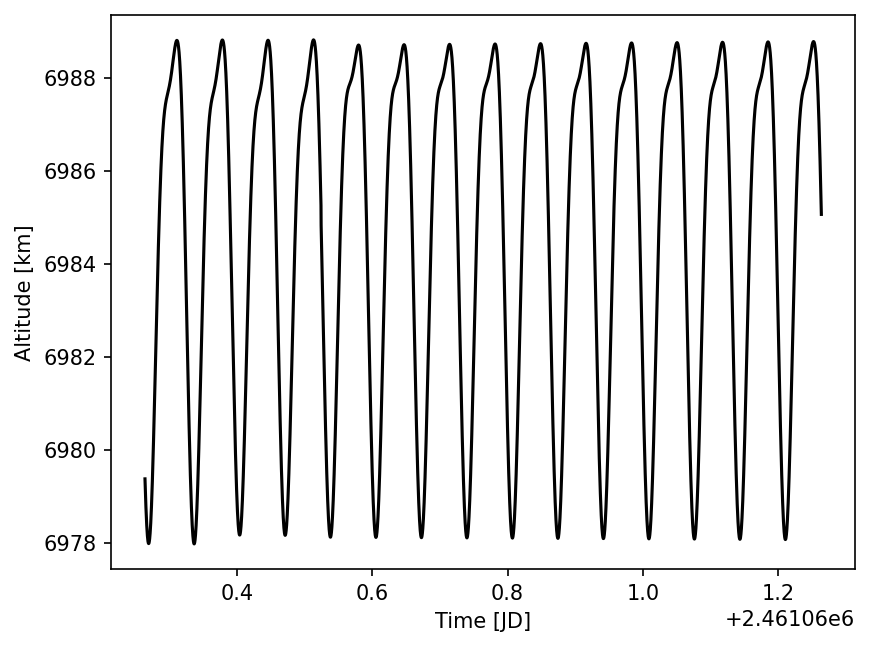

In [17]:
fig, ax = plt.subplots(dpi=150)
ax.plot(t.jd, ps.get_altitude(t), c='k')
ax.set(xlabel='Time [JD]', ylabel='Altitude [km]')